# Prism coupling

Reproducing the results from the paper

From Bloch surface waves to cavity-mode resonances reaching an ultrahigh sensitivity and a figure of merit  Michal Gryga, Dalibor Ciprian, AND Petr Hlubina∗  Department of Physics, Technical University Ostrava, 17. listopadu 2172/15, 708 00 Ostrava-Poruba, Czech Republic *petr.hlubina@vsb.cz  Received 18 October 2023; accepted 31 October 2023; posted 1 November 2023; published 14 November 2023

In [134]:
import PyMoosh as pm
import numpy as  np
import matplotlib.pyplot as plt
%matplotlib widget
#plt.rcParams['figure.dpi'] = 150
from phc_codes.phc_utils import refractive_index, plot_layers

Theta_i = 0

npva = 1.4858 + 0.0001j
nPDMS = lambda x : (1+1.0093/(1-13185.0/x**2))**.5

ni = refractive_index("Quartz_expt")
nf = 1.0 #refractive_index("Water")
nh = refractive_index("TiO2_expt")  # 2.41 + 0.0024j    #
nl = refractive_index("SiO2_expt")  # 1.46 + 0.0010j  #
n_cavity = nl
nglyc = 1.4722 # glycerol

# Two materials of different optical index. The larger the difference in index, the more efficient the mirror will be
tl = 100
th = 60
tl_mod = tl #* 2.9#+ 90
th_mod = th #th *.36 #* 2.9#+ 90
t_cavity = 1000
tqz = 500
tfinal = 0
tglyc = 0
tsup = 500

materials = [
        lambda x : ni(x)**2,    #0
        lambda x : nl(x)**2,    #1
        lambda x : nh(x)**2,    #2
        nf**2,                  #3
        nglyc**2,               #4
        lambda x : n_cavity(x)**2, #5
    ]

lay_pairs = 3

stack = [0, 4] + [2, 1] * lay_pairs + [2, 5, 2] + [1, 2] * lay_pairs + [3] 
thicknesses = [tqz, tglyc] + [th, tl] * lay_pairs + [th_mod, t_cavity, th_mod] + [tl, th] * lay_pairs + [tsup]


prism_coupler = pm.Structure(materials,stack,thicknesses)

print(thicknesses, stack)

List of materials:
Custom dispersive material. Epsilon= <lambda> (wavelength in nm)
Custom dispersive material. Epsilon= <lambda> (wavelength in nm)
Custom dispersive material. Epsilon= <lambda> (wavelength in nm)
Simple, non dispersive: epsilon= (1+0j)
Simple, non dispersive: epsilon= (2.16737284+0j)
Custom dispersive material. Epsilon= <lambda> (wavelength in nm)
[500, 0, 60, 100, 60, 100, 60, 100, 60, 1000, 60, 100, 60, 100, 60, 100, 60, 500] [0, 4, 2, 1, 2, 1, 2, 1, 2, 5, 2, 1, 2, 1, 2, 1, 2, 3]


## dispersion curve

reflection at different angles

In [135]:
n_wls = 1000
angle_i = 0
angle_f = 55
n_angle = 100
prism_coupler.thickness[lay_pairs * 2 + 3] = 550 # modify cavity layer thickness
wl_i = 420
wl_f = 950
polarization = 0 # TE=0, TM=1

Theta_i_deg = np.linspace(angle_i, angle_f, n_angle)  # angle of incidence(degree)

# Generating data arrays -----------------------------------------------
Theta_i = (np.pi / 180) * Theta_i_deg  # in radians
Reflectance = np.zeros((n_wls, n_angle))

for k, theta in enumerate(Theta_i):
    wls, r, t, R, T = pm.spectrum(prism_coupler, theta, polarization, wl_i, wl_f, n_wls)
    Reflectance[:, k] = R.T


### Plot the dispersion calculated

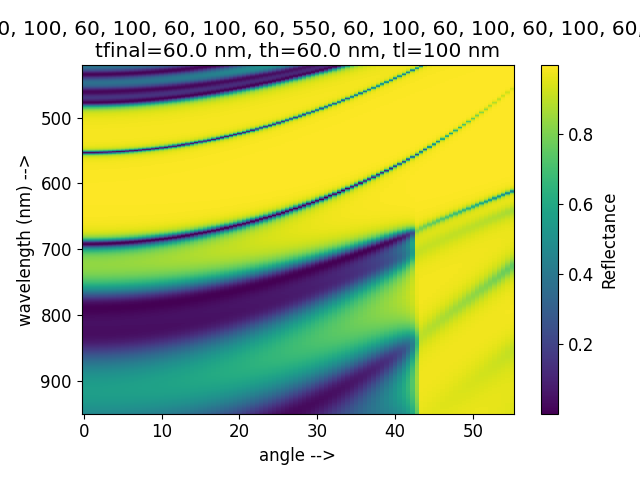

In [136]:
plt.figure(3)
plt.clf()
plt.rcParams.update({'font.size': 12})
Th, Lmda = np.meshgrid(Theta_i_deg, wls)
plt.pcolormesh(Th, Lmda, Reflectance, lw=1,) # cmap="gist_gray")
plt.colorbar(label="Reflectance")
plt.xlabel(r"angle -->")
plt.ylabel(r"wavelength (nm) -->")
plt.title(f"{thicknesses}\ntfinal={th_mod:.1f} nm, th={th:.1f} nm, tl={tl} nm")
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()

## Reflectivity at specific angles

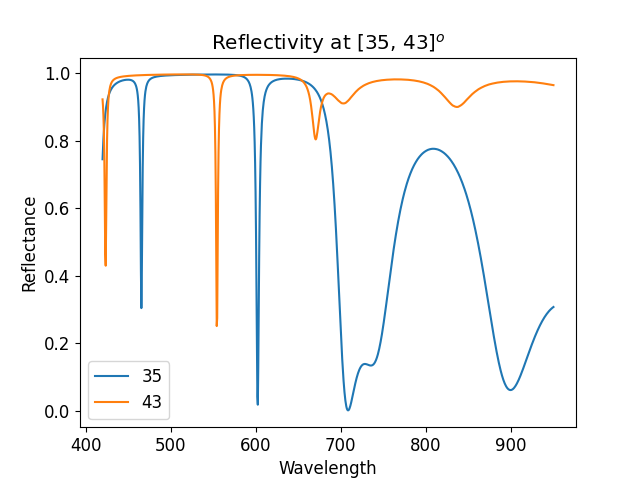

In [137]:
plot_angles = [35, 43]
plt.figure(5)
plt.clf()

for angle in plot_angles:
    _, _, _, rr, _ = pm.spectrum(prism_coupler, angle*np.pi/180, polarization, wl_i, wl_f, n_wls)
    plt.plot(wls, rr)

#plt.legend(plot_angles, title="angle")
plt.xlabel("Wavelength")
plt.ylabel("Reflectance")
plt.legend(plot_angles)
plt.title(f"Reflectivity at {plot_angles}$^o$")
plt.show()

## Reflectivity at specific wavelength

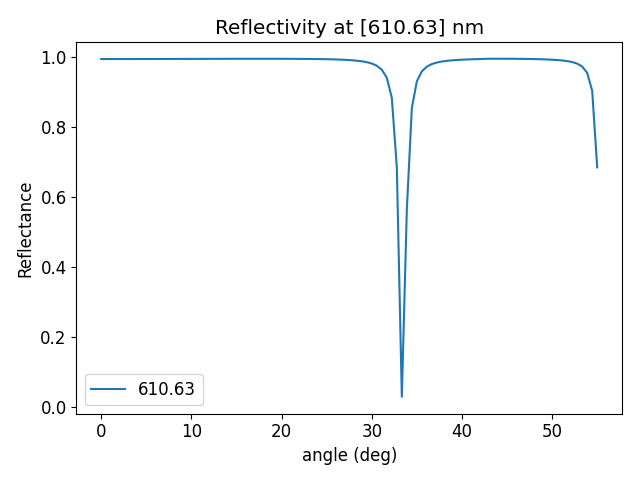

In [138]:
plot_wls = [610.63]
plt.figure(6)
plt.clf()

for wl in plot_wls:
    plt.plot(Theta_i_deg, Reflectance[np.argmin(np.abs(wls - wl)), :])

#plt.legend(plot_wls, title="angle")
plt.xlabel("angle (deg)")
plt.ylabel("Reflectance")
plt.title(f"Reflectivity at {plot_wls} nm")
plt.legend(plot_wls)
plt.tight_layout()
plt.show()

Pixels horizontally: 2772
Incidence in degrees: 43.00000000000001
E//, TE, s polarization
Pixels vertically: 1315


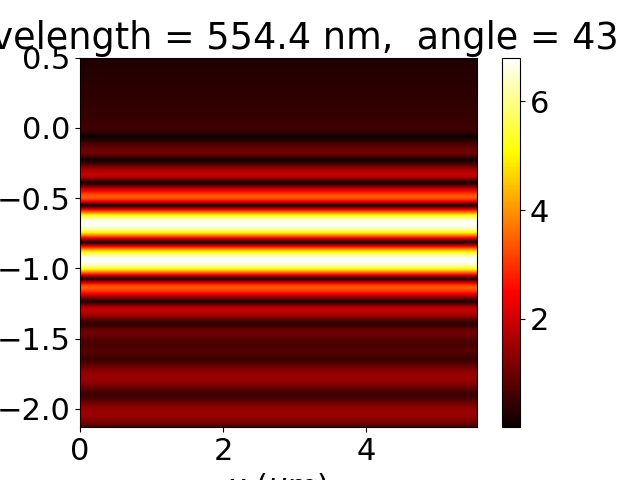

In [154]:
wl = 554.4
angle = 43
domain = pm.Window(10 * wl, 0.3, 2.0, 2.0)
beam = pm.Beam(wl, angle / 180 * np.pi, polarization, 10 * wl)

E = pm.field(prism_coupler, beam, domain)
norm_E = abs(E)
#norm_E /= max(norm_E[:, 100])
total_thickness = sum(thicknesses)
plt.figure(7)
plt.clf()
ax = plt.axes()
plt.imshow(
     norm_E[::-1, :],
    cmap="hot",
    extent=[0, domain.width/1000, +0.5 - total_thickness/1000,  0.5],
    aspect="auto",
)
plt.colorbar()
plt.xlabel(r"x ($\mu$m)")
plt.ylabel(r"z ($\mu$m)")
plt.title(f"wavelength = {wl} nm,  angle = {angle}")
#ax.invert_yaxis()
plt.show()

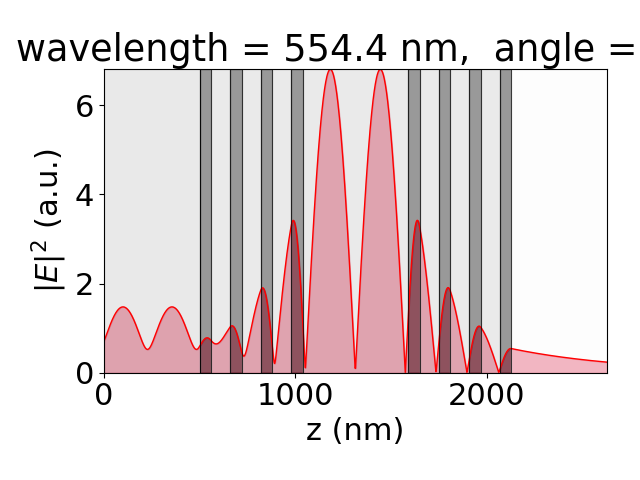

In [147]:
#line plot  of the energy density
plt.figure(8)
plt.clf()
ax = plt.axes()
lineplot_x = 1050
#plt.plot(abs(np.sum(E, axis=1)))
xx, yy = np.linspace(0, total_thickness, len(norm_E[:, lineplot_x])), norm_E[:, lineplot_x]
plt.plot(xx, yy, "r", lw=1)
plt.fill_between(xx, yy, alpha=0.5, color='crimson')
plt.xlabel(r"z (nm)")
plt.ylabel("$|E|^2$ (a.u.)")


'''ax.set_xticks(
    np.linspace(0, domain.ny * domain.py, 8),
    ["%.1f" % a for a in np.linspace(tsup/1000- np.sum(prism_coupler.thickness)/1000, tsup/1000, 8)]
)'''
plot_layers(prism_coupler, ylim=max(yy))
plt.title(f"wavelength = {wl} nm,  angle = {angle}")
#plt.legend(["Integrated intensity", f"intensity at x={lineplot_x*30}"])
plt.tight_layout()
plt.show()



### convert $\lambda -\theta$ to $\omega- k_x$

In [148]:
a = th + tl # lattice parameter 
def lmda_theta_to_omega_k(lmda, theta):
    """convert lambda-theta data to omega/c-k_x data for phc
    lmda : float , in units of nm
    theta : float , in units of degree"""
    neff = 1.13
    omega = a / lmda
    k_x = neff* omega * np.sin(theta * np.pi / 180)
    return omega, k_x

y_size, x_size = Reflectance.shape
Omega = np.zeros_like(Reflectance)
Kx = np.zeros_like(Reflectance)
for i in range(y_size):
    for j in range(x_size):
        Omega[i,j], Kx[i,j] = lmda_theta_to_omega_k(Lmda[i,j], Th[i,j])

### plot $\omega - k_x$

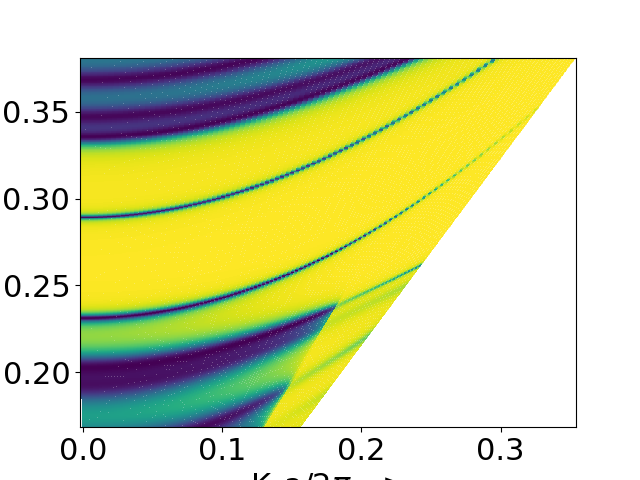

In [149]:
plt.figure(9)
plt.clf()
fig, ax = plt.subplots()
cplot = ax.pcolormesh(
    Kx, Omega, Reflectance, antialiased=True
)  # x_tick = row index, y_tick = column index
#fig.colorbar(cplot, label="log$_{10}$(count)")
#ax.plot([0.167, 0.37], [0.167, 0.37])
plt.xlabel(r"K$_x$a/2$\pi$ -->")
plt.ylabel(r"$\omega$a/2$\pi$c -->")
plt.show()

### convert $\lambda -\theta$ to $\lambda- n_{eff}$

In [150]:
a = th + tl # lattice parameter 
def theta_to_n(theta):
    """convert lambda-theta data to omega/c-k_x data for phc
    lmda : float , in units of nm
    theta : float , in units of degree"""
    n_sub = 1.48
    n_eff = n_sub *  np.sin(theta * np.pi / 180)
    return n_eff

y_size, x_size = Reflectance.shape
nn = np.zeros_like(Reflectance)
for i in range(y_size):
    for j in range(x_size):
        nn[i,j] = theta_to_n(Th[i,j])


### plot $\lambda - k_T$

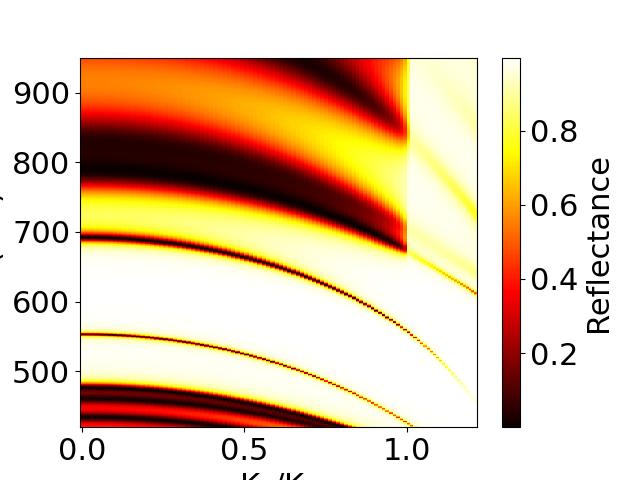

In [151]:
plt.figure(10)
plt.clf()
fig, ax = plt.subplots()
cplot = ax.pcolormesh(
    nn, Lmda, Reflectance, antialiased=True, cmap='hot'
)  # x_tick = row index, y_tick = column index
fig.colorbar(cplot, label="Reflectance")
#ax.plot([1, 1], [420, 950])
plt.xlabel(r"K$_T$/K$_0$")
plt.ylabel(r"$\lambda$ (nm)")
#ax.invert_yaxis()
plt.show()

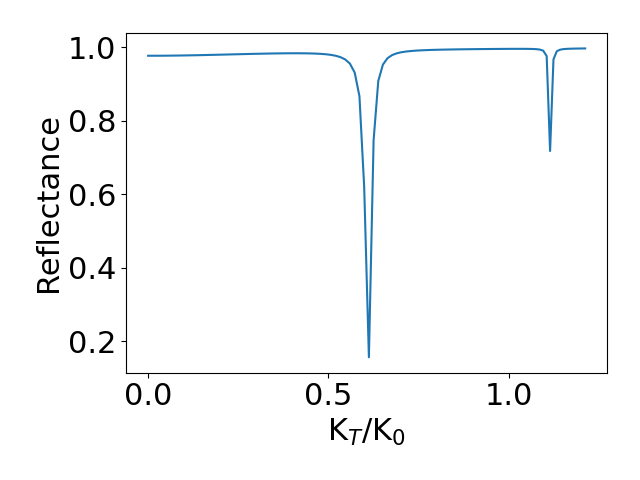

In [152]:
plot_wl = [510]
plt.figure(11)
plt.clf()
plt.rcParams.update({'font.size': 22})

for wl in plot_wl:
    plt.plot(nn[0,:], Reflectance[np.argmin(np.abs(wls-wl)), :])

#plt.legend(plot_wl, title="angle")
plt.xlabel(r"K$_T$/K$_0$")
plt.ylabel("Reflectance")
#plt.title(f"Reflectivity at {plot_wl} nm")
plt.tight_layout()
plt.show()